In [12]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [13]:
# 2. LOAD DATASET
# =========================
train_data = pd.read_csv("fashion-mnist_train.csv")
test_data = pd.read_csv("fashion-mnist_test.csv")

In [14]:
# =========================
# 3. SPLIT FEATURES & LABELS
# =========================
x_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

x_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

In [15]:
# =========================
# 4. DATA PREPROCESSING
# =========================
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

In [16]:
# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [17]:
# 5. BUILD CNN MODEL
# =========================
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3), activation='relu'),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(10, activation='softmax')
])

C:\Users\Sangeeta Behera\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# =========================
# 6. COMPILE MODEL
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# =========================
# 7. TRAIN MODEL
# =========================
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.8023 - loss: 0.5371 - val_accuracy: 0.8705 - val_loss: 0.3604
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8750 - loss: 0.3436 - val_accuracy: 0.8872 - val_loss: 0.3125
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.8926 - loss: 0.2946 - val_accuracy: 0.8999 - val_loss: 0.2742
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9039 - loss: 0.2607 - val_accuracy: 0.9038 - val_loss: 0.2710
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9124 - loss: 0.2341 - val_accuracy: 0.9114 - val_loss: 0.2494
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9217 - loss: 0.2099 - val_accuracy: 0.9057 - val_loss: 0.2694
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.9284 - loss: 0.1907 - val_accuracy: 0.9131 - val_loss: 0.2644
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9364 -

In [20]:
# =========================
# 8. EVALUATE MODEL
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9113 - loss: 0.2858
Test Accuracy: 0.911300003528595


In [21]:
# =========================
# 9. PREDICTION (OUTPUT)
# =========================
predictions = model.predict(x_test)

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


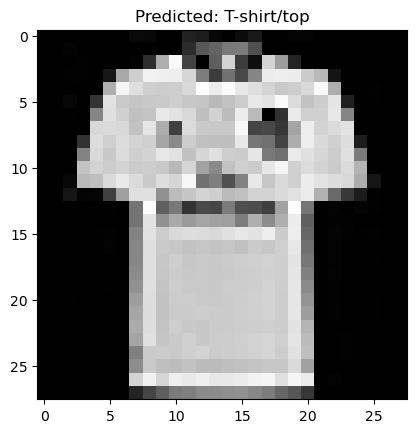

In [22]:
# Show result
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted: " + class_names[np.argmax(predictions[0])])
plt.show()